<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [265]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [266]:
# loading the data: Wholesale customers data
# 1. Load Data
df = pd.read_csv('../data/Wholesale customers data.csv')

# 2. Inspect Data
print("Missing values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

# 3. Separate continuous features from categorical demographics
# 'Channel' and 'Region' are nominal variables and shouldn't be included in Euclidean distance metrics
features = df.drop(columns=['Channel', 'Region'])

# 4. Handle Skewness (Log Transformation)
# Financial spend data is right-skewed; log1p normalizes scale variance
features_log = np.log1p(features)

# 5. Standardize Features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_log)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
customers_scale = features_scaled

print("\nScaled Data Head:")
display(features_scaled_df.head())

Missing values:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Data Types:
 Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Scaled Data Head:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [267]:
# Calculate total spending per customer and check the Pareto principle
# 20% of customers should account for a large share of total revenue in a retail dataset.
df['Total_Spend'] = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].sum(axis=1)

df_sorted = df.sort_values(by='Total_Spend', ascending=False).reset_index(drop=True)
df_sorted['Cumulative_Spend'] = df_sorted['Total_Spend'].cumsum()
df_sorted['Spend_Percentage'] = (df_sorted['Cumulative_Spend'] / df_sorted['Total_Spend'].sum()) * 100
df_sorted['Customer_Percentage'] = ((df_sorted.index + 1) / len(df_sorted)) * 100

top_20_percent = df_sorted[df_sorted['Customer_Percentage'] <= 20].iloc[-1]
print(f"Top 20% of customers account for {top_20_percent['Spend_Percentage']:.2f}% of overall total spending.")
print(f"Customer share considered: {top_20_percent['Customer_Percentage']:.2f}%")

Top 20% of customers account for 42.90% of overall total spending.
Customer share considered: 20.00%


**Your observations here**

- ex.: Frozen, Grocery, Milk and Detergents Paper have a high...
- ...



# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

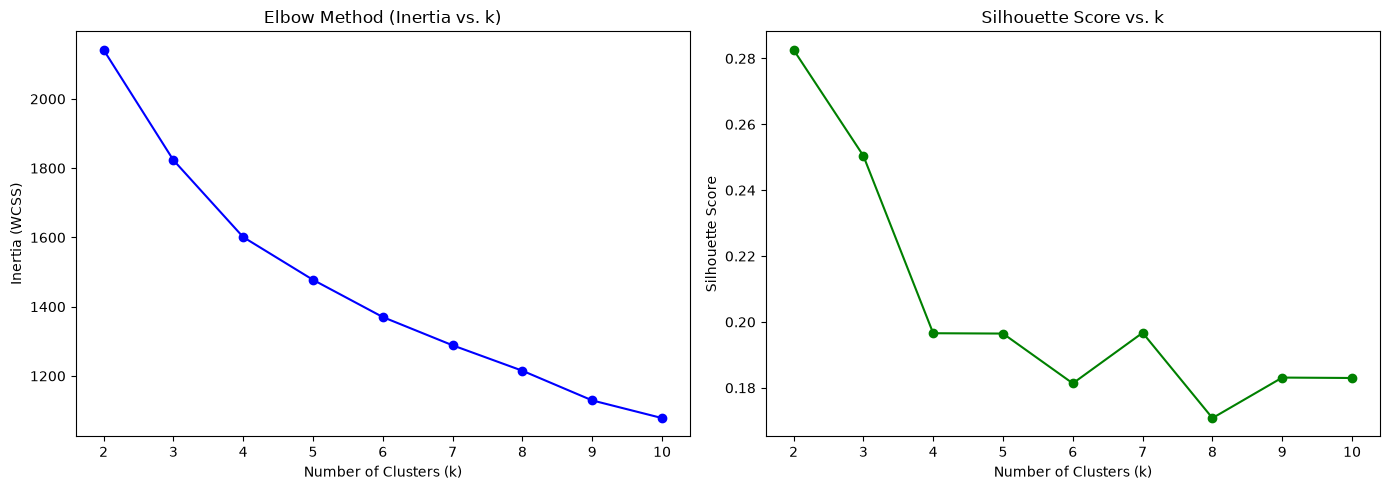

Cluster assignment complete for k=2.
Silhouette score: 0.2826


In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Prepare and scale data
features = df.drop(columns=['Channel', 'Region'], errors='ignore')
features_log = np.log1p(features)
scaler = StandardScaler()
customers_scale = scaler.fit_transform(features_log)

# 2. Run K-Means metrics loop
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customers_scale)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(customers_scale, kmeans.labels_))

# 3. Plot results
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax[0].plot(k_range, inertia, marker='o', color='b')
ax[0].set_title('Elbow Method (Inertia vs. k)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia (WCSS)')

# Silhouette Score Curve
ax[1].plot(k_range, silhouette_scores, marker='o', color='g')
ax[1].set_title('Silhouette Score vs. k')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# 4. Fit final K-Means model using the best-supported choice for this dataset
optimal_k = 2
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = final_kmeans.fit_predict(customers_scale)

print(f"Cluster assignment complete for k={optimal_k}.")
print("Silhouette score:", round(silhouette_score(customers_scale, df['KMeans_Cluster']), 4))

**Your comment here**

-  ...
-  ...

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

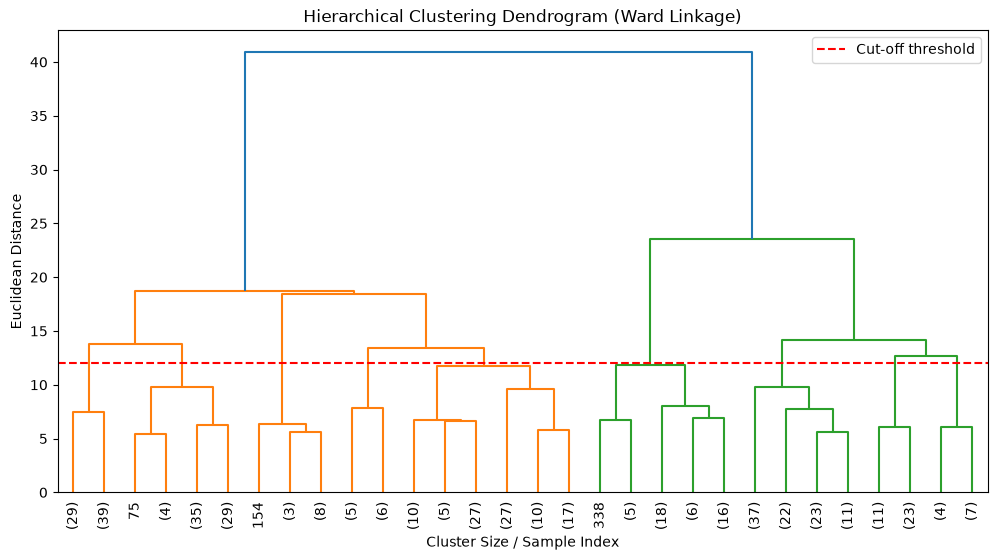

In [269]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1. Compute Ward linkage matrix on scaled data
linked = linkage(customers_scale, method='ward')

# 2. Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=12, color='r', linestyle='--', label='Cut-off threshold')
plt.legend()
plt.show()

# 3. Assign hierarchical cluster labels
df['Hierarchical_Cluster'] = fcluster(linked, t=3, criterion='maxclust')

# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

Explained Variance Ratio by PC1 & PC2: [0.45822166 0.264592  ]
Total Explained Variance: 72.28%


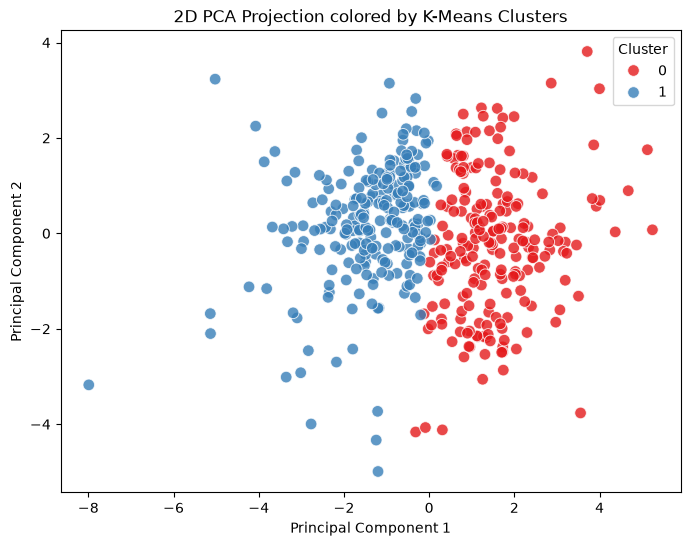

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. PCA Dimensionality Reduction
pca = PCA(n_components=2)
pca_components = pca.fit_transform(customers_scale)

print(f"Explained Variance Ratio by PC1 & PC2: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_):.2%}")

# 2. Visualize Clusters in 2D Space
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    hue=df['KMeans_Cluster'],
    palette='Set1',
    s=70,
    alpha=0.8
)
plt.title('2D PCA Projection colored by K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### Looking to the elbow we can choose 2 like the correct number of clusters

In [271]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_2.fit(customers_scale)

df['labels'] = kmeans_2.labels_
df['kmeans_labels'] = df['labels']
print('KMeans cluster counts:')
print(df['labels'].value_counts().sort_index())

KMeans cluster counts:
labels
0    208
1    232
Name: count, dtype: int64


In [272]:
# Keep the K-Means labels attached to the original data for later comparison plots.
df['kmeans_labels'] = df['labels']
print(df[['labels', 'kmeans_labels']].head())

   labels  kmeans_labels
0       0              0
1       0              0
2       0              0
3       1              1
4       0              0


Count the values in `labels`.

In [273]:
# Count the K-Means cluster labels currently stored in the dataframe
print(df['labels'].value_counts().sort_index())

labels
0    208
1    232
Name: count, dtype: int64


# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [274]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Preprocess and scale continuous spend features
features = df.drop(columns=['Channel', 'Region'], errors='ignore')
features_log = np.log1p(features)
scaler = StandardScaler()
customers_scale = scaler.fit_transform(features_log)

# 2. Instantiate and fit DBSCAN model
dbscan = DBSCAN(eps=1.8, min_samples=12)
dbscan_labels = dbscan.fit_predict(customers_scale)

# 3. Create clean_customers and assign DBSCAN labels
clean_customers = df.copy()
clean_customers['labels_DBSCAN'] = dbscan_labels
clean_customers['dbscan_labels'] = dbscan_labels

# 4. Display the cluster size distribution
print('--- Challenge 5: DBSCAN Cluster Sizes ---')
print('Note: Label -1 represents noise/outliers')
print(clean_customers['labels_DBSCAN'].value_counts().sort_index())

# 5. Display sample rows with assigned DBSCAN clusters
print('\nFirst 5 rows of clean_customers with assigned DBSCAN clusters:')
display(clean_customers.head())

--- Challenge 5: DBSCAN Cluster Sizes ---
Note: Label -1 represents noise/outliers
labels_DBSCAN
-1     43
 0    190
 1    207
Name: count, dtype: int64

First 5 rows of clean_customers with assigned DBSCAN clusters:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spend,KMeans_Cluster,Hierarchical_Cluster,labels,kmeans_labels,labels_DBSCAN,dbscan_labels
0,2,3,12669,9656,7561,214,2674,1338,34112,0,2,0,0,0,0
1,2,3,7057,9810,9568,1762,3293,1776,33266,0,3,0,0,0,0
2,2,3,6353,8808,7684,2405,3516,7844,36610,0,3,0,0,0,0
3,1,3,13265,1196,4221,6404,507,1788,27381,1,1,1,1,1,1
4,2,3,22615,5410,7198,3915,1777,5185,46100,0,3,0,0,0,0


Count the values in `labels_DBSCAN`.

In [275]:
# Count the values in labels_DBSCAN
print(clean_customers['labels_DBSCAN'].value_counts().sort_index())

labels_DBSCAN
-1     43
 0    190
 1    207
Name: count, dtype: int64


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [276]:
def plot_scatter(x, y, hue, data, title):
    sns.scatterplot(data=data, x=x, y=y, hue=hue, palette='Set1')
    plt.title(title)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Reduce features to 2 Principal Components for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(customers_scale)

# Append PCA components to clean_customers
clean_customers['PC1'] = pca_components[:, 0]
clean_customers['PC2'] = pca_components[:, 1]

df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

# 2. Plot K-Means and DBSCAN clusters in PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='labels',
    palette='Set1',
    s=60,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('K-Means in PCA space')

sns.scatterplot(
    data=clean_customers,
    x='PC1',
    y='PC2',
    hue='labels_DBSCAN',
    palette='Set1',
    s=60,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('DBSCAN in PCA space')

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 3. Spend profiling by DBSCAN cluster on the original scale
spend_cols = features.columns

print("\n--- Mean Spend per DBSCAN Cluster (Original Scale) ---")
display(clean_customers.groupby('labels_DBSCAN')[spend_cols].mean().round(2))

SyntaxError: invalid syntax (2552396349.py, line 51)

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

In [ ]:
# Grocery vs Fresh for KMeans and DBSCAN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Grocery', y='Fresh', hue='labels', palette='Set1')
plt.title('K-Means: Grocery vs Fresh')

plt.subplot(1, 2, 2)
sns.scatterplot(data=clean_customers, x='Grocery', y='Fresh', hue='labels_DBSCAN', palette='Set1')
plt.title('DBSCAN: Grocery vs Fresh')

plt.tight_layout()
plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

In [ ]:
# Frozen vs Delicassen for KMeans and DBSCAN
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Frozen', y='Delicassen', hue='labels', palette='Set1')
plt.title('K-Means: Frozen vs Delicassen')

plt.subplot(1, 2, 2)
sns.scatterplot(data=clean_customers, x='Frozen', y='Delicassen', hue='labels_DBSCAN', palette='Set1')
plt.title('DBSCAN: Frozen vs Delicassen')

plt.tight_layout()
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [ ]:
# Compare average spend by K-Means and DBSCAN clusters
print('--- K-Means cluster means ---')
display(df.groupby('labels')[features.columns].mean().round(2))

print('\n--- DBSCAN cluster means ---')
display(clean_customers.groupby('labels_DBSCAN')[features.columns].mean().round(2))

Which algorithm appears to perform better?

**Your observations here**

- 

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

In [ ]:
# Bonus Challenge 2 - Changing K-Means Number of Clusters
# Compare several k values visually and using silhouette score

for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(customers_scale)
    score = silhouette_score(customers_scale, labels)
    print(f'k={k} | silhouette={score:.4f} | cluster sizes={pd.Series(labels).value_counts().sort_index().to_dict()}')

# Quick visual comparison for 2 and 3 clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, k in zip(axes, [2, 3]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(customers_scale)
    ax.scatter(customers_scale[:, 0], customers_scale[:, 1], c=labels, cmap='Set1', s=40)
    ax.set_title(f'K-Means with k={k}')
    ax.set_xlabel('Scaled Fresh')
    ax.set_ylabel('Scaled Grocery')

plt.tight_layout()
plt.show()

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [ ]:
# Bonus Challenge 3 - Changing DBSCAN eps and min_samples
# Test a few parameter values to see how the cluster structure changes.

for eps in [0.5, 1.0, 1.5, 1.8, 2.0]:
    for min_samples in [5, 8, 12]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(customers_scale)
        counts = pd.Series(labels).value_counts().sort_index().to_dict()
        print(f'eps={eps}, min_samples={min_samples} -> {counts}')

# One example visualization using a different setting
for eps, min_samples in [(0.5, 5), (1.8, 12)]:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(customers_scale)
    plt.figure(figsize=(6, 5))
    plt.scatter(customers_scale[:, 0], customers_scale[:, 1], c=labels, cmap='Set1', s=40)
    plt.title(f'DBSCAN with eps={eps}, min_samples={min_samples}')
    plt.xlabel('Scaled Fresh')
    plt.ylabel('Scaled Grocery')
    plt.show()

**Your comment here**

- 